<a href="https://colab.research.google.com/github/eehujnihs21-stack/app0320/blob/main/2555037%EC%8B%A0%EC%A3%BC%ED%9D%AC_FAST_API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**FastAPI** 기반 격언 관리 및 분석 시스템

##1. 프로젝트 개요
프로젝트 명: FastAPI 및 Gradio 기반 격언 관리 및 데이터 분석 시스템

목적: 웹 크롤링을 통한 비정형 데이터 수집, 관계형 DB(SQLite) 연동, RESTful API 설계 및 데이터 시각화 대시보드 통합 구현

기술 스택:

Language: Python 3.x

Backend: FastAPI, Uvicorn, Pydantic

Frontend: Gradio (Integrated with FastAPI)

Database: SQLite3

Library: BeautifulSoup4, HTTPX, Deep-translator, Pandas, Pyngrok

##2. 주요 구현 기능

(1).데이터 수집 (Crawling): HTTPX와 BeautifulSoup4를 활용해 외부 웹사이트(quotes.toscrape.com)에서 격언 20개를 동적으로 수집하고 DB에 저장하는 파이프라인 구축.
(2). 데이터베이스 (DB): 격언의 고유 ID, 내용, 저자, 태그 정보를 관리하는 quotes 테이블 설계.

(3). 백엔드 API (CRUD):

GET: 전체 격언 목록 조회

POST: 신규 격언 등록

PUT: 특정 ID의 격언 내용 수정 (과제 핵심 요구사항)

DELETE: 특정 격언 삭제

(4). 프론트엔드 대시보드 (Gradio):

실시간 검색: 저자 및 내용 기반 필터링 기능.

감성 필터링: 격언의 키워드를 분석하여 카테고리별(사랑, 성공 등) 분류 제공.

실시간 번역: deep-translator를 연동하여 영어 격언을 한국어로 즉시 번역.

(5). 데이터 시각화: 수집된 데이터의 단어 빈도수 및 저자별 점유율을 막대그래프(BarPlot)로 시각화하여 데이터 인사이트 제공.

##3. 시스템 아키텍처

사용자가 UI에서 요청을 보내면 FastAPI 백엔드가 SQLite DB와 통신하여 데이터를 처리하며, 외부 배포 도구인 ngrok을 통해 로컬 서버를 공용 URL로 변환하여 서비스합니다.

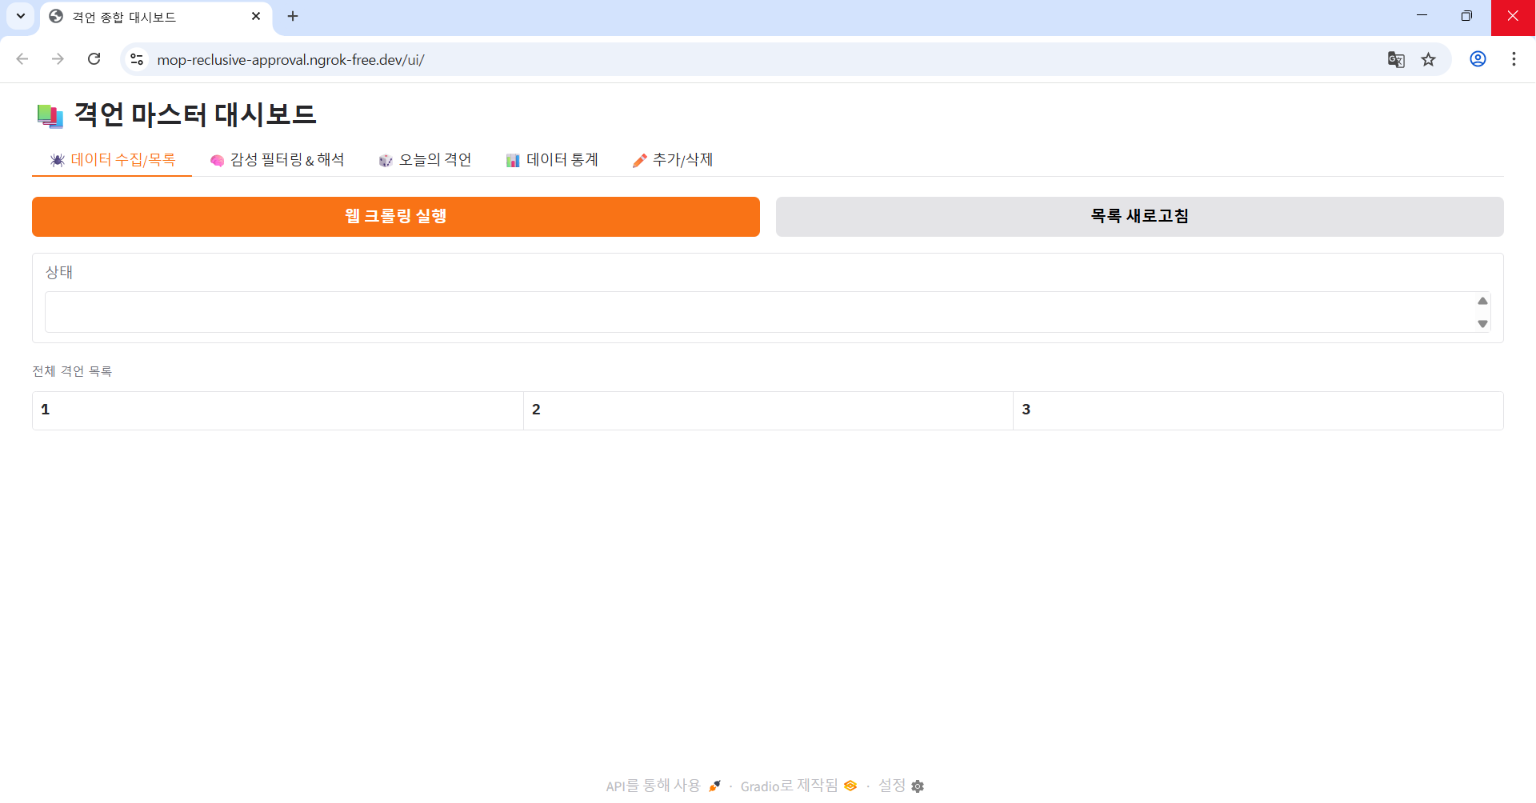

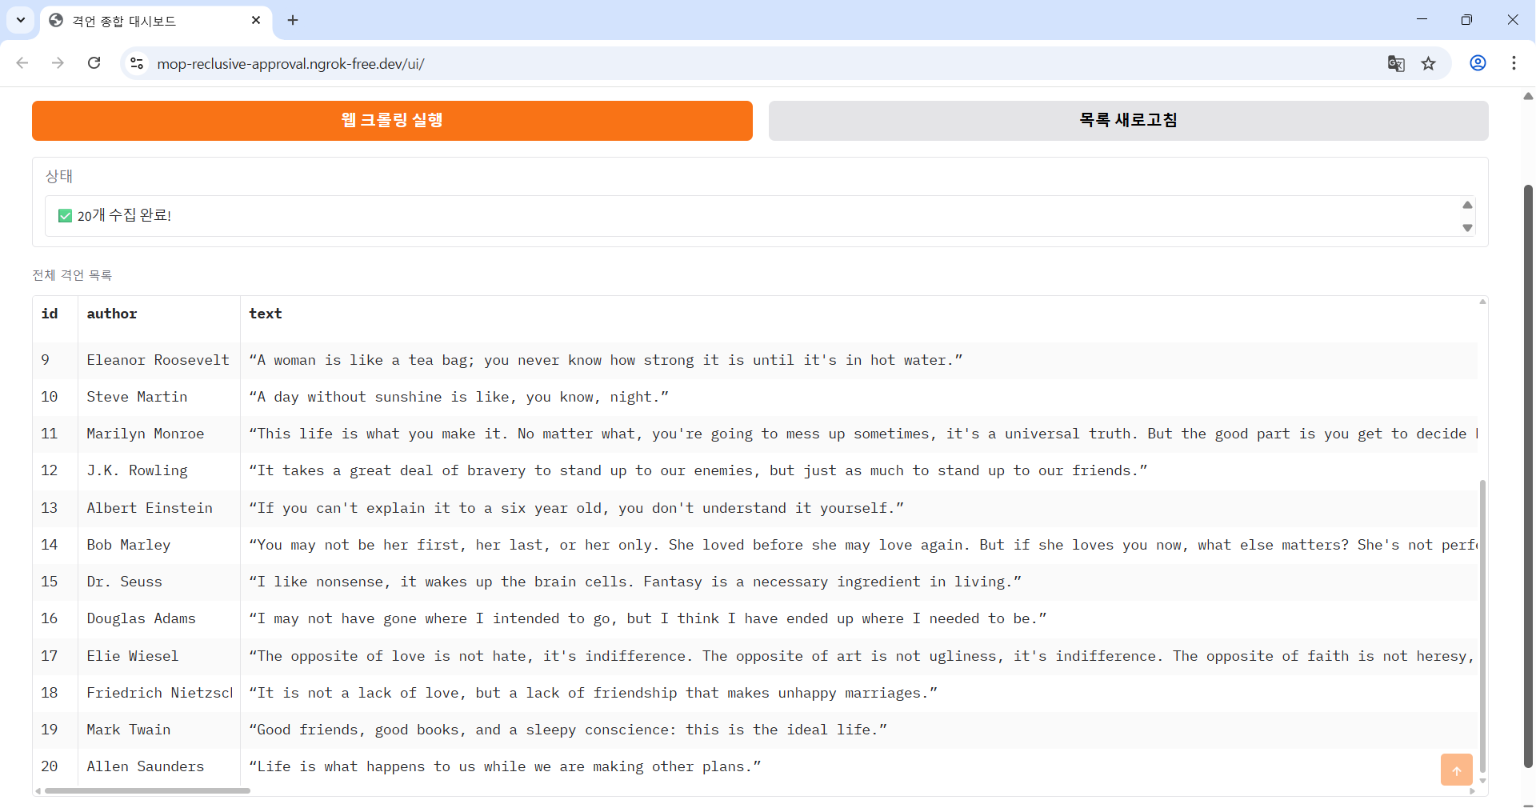

##4. 핵심 코드 상세 설명


① 서비스 통합: mount_gradio_app
FastAPI 인스턴스에 Gradio UI를 특정 경로(/ui)로 마운트하여 단일 서버 포트(8000)에서 API 명세서(Swagger)와 사용자용 대시보드를 동시에 제공합니다. 이는 시스템 자원 관리와 배포 편의성을 크게 향상시킵니다.

② 완전한 CRUD: @app.put("/quotes/{qid}")
RESTful API 설계 원칙에 따라 특정 리소스를 수정하는 PUT 메서드를 구현했습니다. Pydantic의 BaseModel을 활용해 데이터 타입을 강제함으로써 데이터 무결성을 보장하며, 수정 성공 여부를 HTTP 상태 코드로 반환합니다.

③ 사용자 경험: GoogleTranslator 실시간 번역
수집된 비정형 텍스트(영어)를 사용자 친화적인 정보로 변환하기 위해 실시간 번역 로직을 도입했습니다. 단순 데이터 조회를 넘어 실제 서비스 가능한 수준의 인터페이스를 목표로 설계되었습니다.

④ 데이터 인사이트: Counter & gr.BarPlot
비정형 텍스트에서 불용어(Stopwords)를 제외한 핵심 키워드를 추출하고 빈도수를 계산합니다. 이를 시각화함으로써 전체 데이터의 주제(Theme)와 저자 분포를 직관적으로 파악할 수 있는 데이터 분석 기능을 강화했습니다.

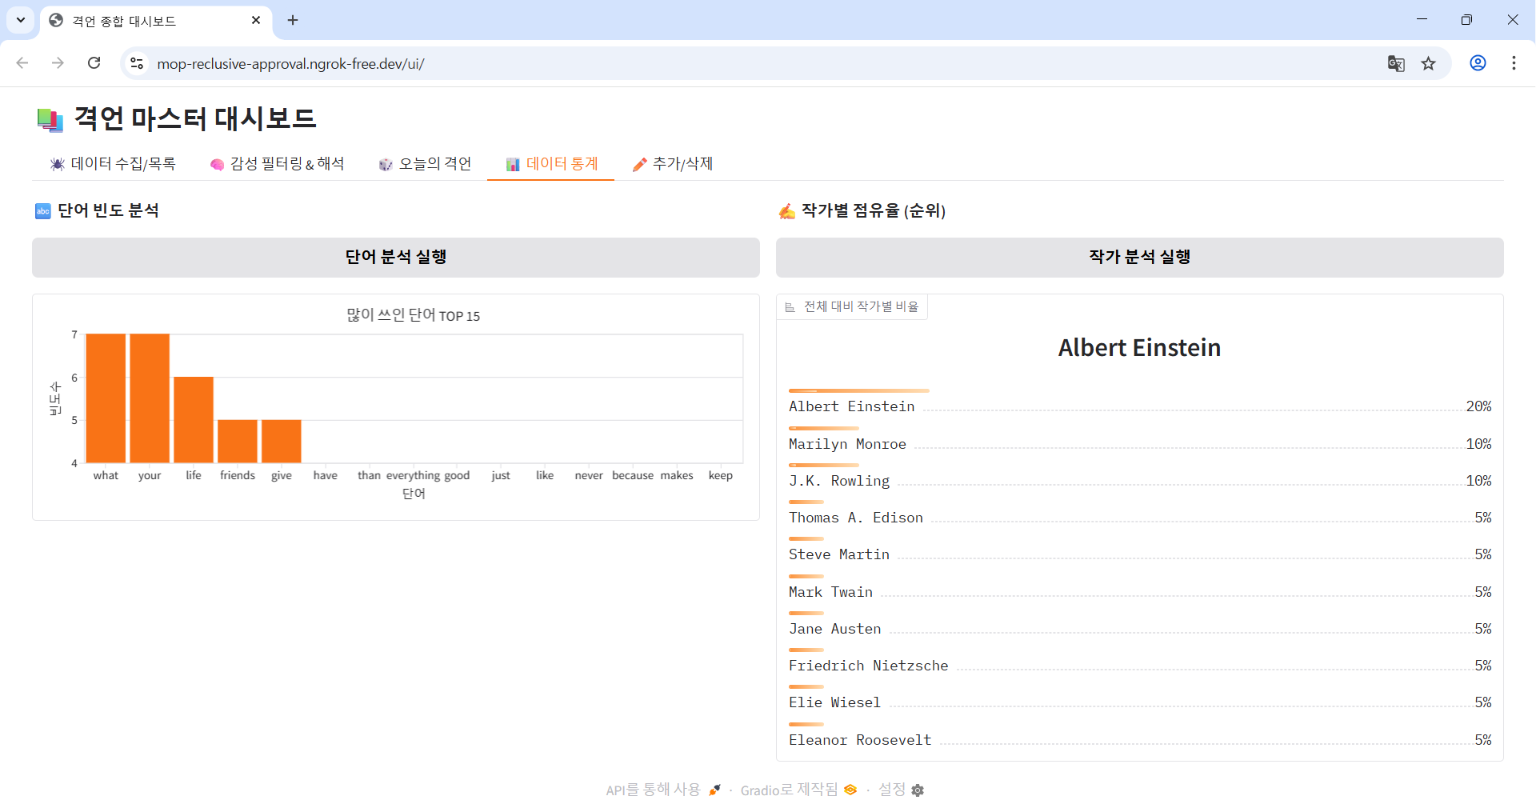

##5. 실행 및 확인 방법

(1). API 테스트: [ngrok_URL]/docs에 접속하여 Swagger UI를 통해 각 엔드포인트(CRUD) 테스트 가능.

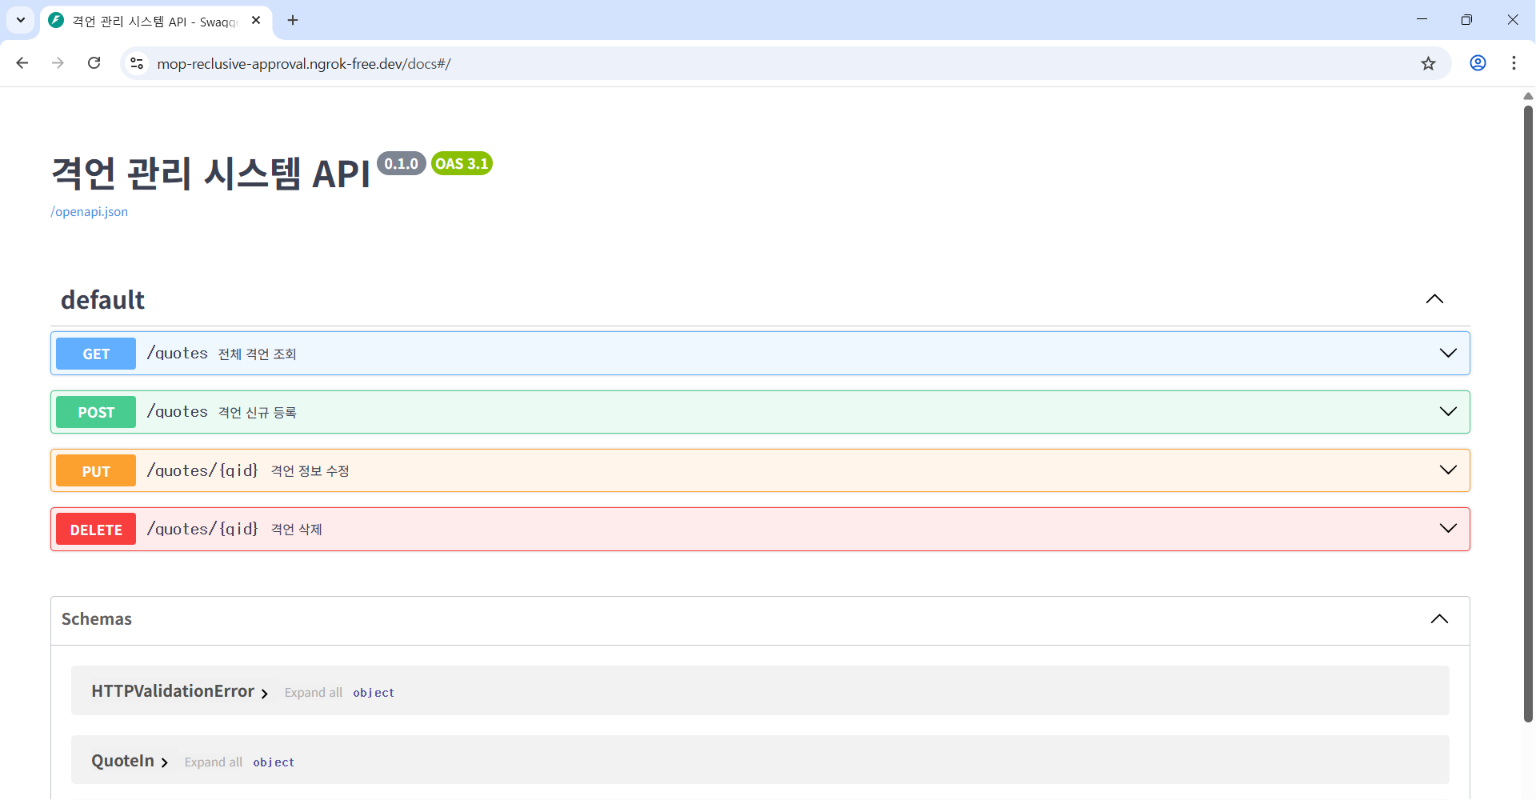

(2). 사용자 UI: [ngrok_URL]/ui에 접속하여 데이터 수집, 검색, 시각화 차트 확인 가능.